In [10]:
import qutip
import matplotlib.pyplot as plt
import numpy as np
import qutip
from qutip import Bloch, QobjEvo, basis, sesolve, sigmax, sigmay, sigmaz, tensor, qeye
from qutip import basis, sesolve, sigmax, sigmay, sigmaz, expect

%matplotlib inline

In [11]:
psi_x = (basis(2, 0) + basis(2, 1)).unit()
psi_mx = (basis(2, 0) - basis(2, 1)).unit()
psi_y = (basis(2, 0) + 1j*basis(2, 1)).unit()
psi_my = (basis(2, 0) - 1j*basis(2, 1)).unit()
psi_z = basis(2, 0)
psi_mz = basis(2, 1)
psi_00=tensor(basis(2,0),basis(2,0))
psi_10=tensor(basis(2,1),basis(2,0))
psi_01=tensor(basis(2,0),basis(2,1))
psi_11=tensor(basis(2,1),basis(2,1))

In [4]:
# b = Bloch()
# b.add_states(psi_x)
# b.show()

In [12]:
def H(t, args):
    omega = args["omega"]
    omega0 = args["omega0"]
    omega1 = args["omega1"]
    
    Hx = -0.5 * omega1 * np.cos(omega * t) * sigmax()
    Hy =  0.5 * omega1 * np.sin(omega * t) * sigmay()
    Hz = -0.5 * omega0 * sigmaz()
    
    return Hx + Hy + Hz

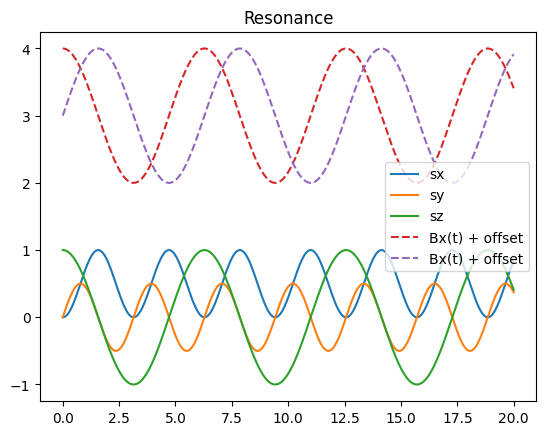

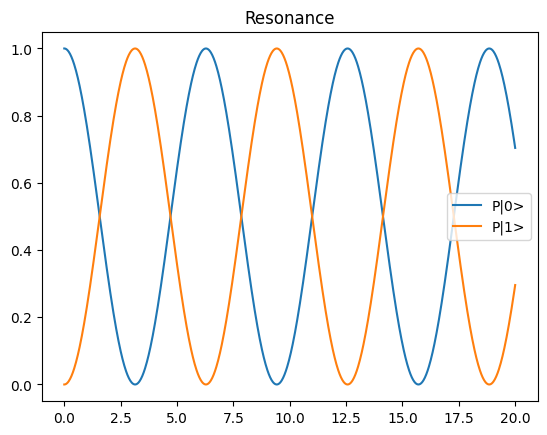

In [ ]:
tlist = np.linspace(0, 20, 1000)
params = {"omega": 1, "omega0": 1, "omega1": 1}
psi0 = basis(2, 0)

result = sesolve(H, psi0, tlist, args=params)
sx = expect(sigmax(), result.states)
sy = expect(sigmay(), result.states)
sz = expect(sigmaz(), result.states)

Bx = params["omega1"] * np.cos(params["omega"] * tlist)
By = params["omega1"] * np.sin(params["omega"] * tlist)


plt.plot(tlist, sx, label="sx")
plt.plot(tlist, sy, label="sy")
plt.plot(tlist, sz, label="sz")
plt.plot(tlist, Bx + 3, "--", label="Bx(t) + offset")
plt.plot(tlist, By + 3, "--", label="Bx(t) + offset")
plt.legend()
plt.title("Resonance")
plt.show()


prob_0 = []
prob_1 = []

for state in result.states:
    psi = state.full().flatten()
    prob_0.append(abs(psi[0])**2)
    prob_1.append(abs(psi[1])**2)

plt.title("Resonance")
plt.plot(tlist, prob_0, label = "P|0>")
plt.plot(tlist, prob_1, label = "P|1>")
plt.legend()
plt.show()

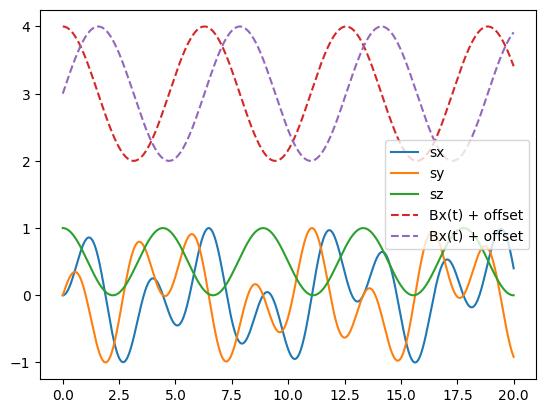

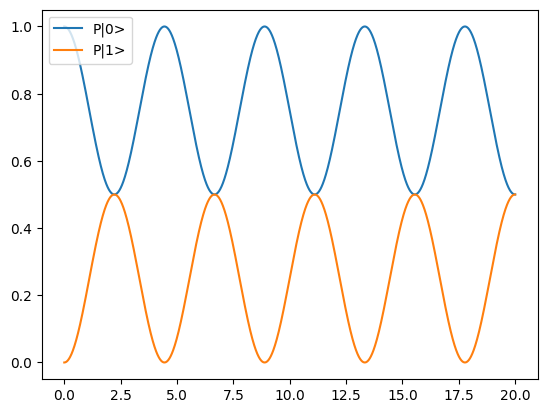

In [35]:
tlist = np.linspace(0, 20, 2000)
params = {"omega": 1, "omega0": 2, "omega1": 1} #
psi0 = basis(2, 0)

result = sesolve(H, psi0, tlist, args=params)
sx = expect(sigmax(), result.states)
sy = expect(sigmay(), result.states)
sz = expect(sigmaz(), result.states)
Bx = params["omega1"] * np.cos(params["omega"] * tlist)
By = params["omega1"] * np.sin(params["omega"] * tlist)

plt.plot(tlist, sx, label = "sx")
plt.plot(tlist, sy, label = "sy")
plt.plot(tlist, sz, label = "sz")
plt.plot(tlist, Bx + 3, "--", label="Bx(t) + offset")
plt.plot(tlist, By + 3, "--", label="Bx(t) + offset")
plt.legend()
# plt.title("Resonance")
plt.show()


prob_0 = []
prob_1 = []

for state in result.states:
    psi = state.full().flatten()
    prob_0.append(abs(psi[0])**2)
    prob_1.append(abs(psi[1])**2)

# plt.title("Resonance")
plt.plot(tlist, prob_0, label = "P|0>")
plt.plot(tlist, prob_1, label = "P|1>")
plt.legend()
plt.show()

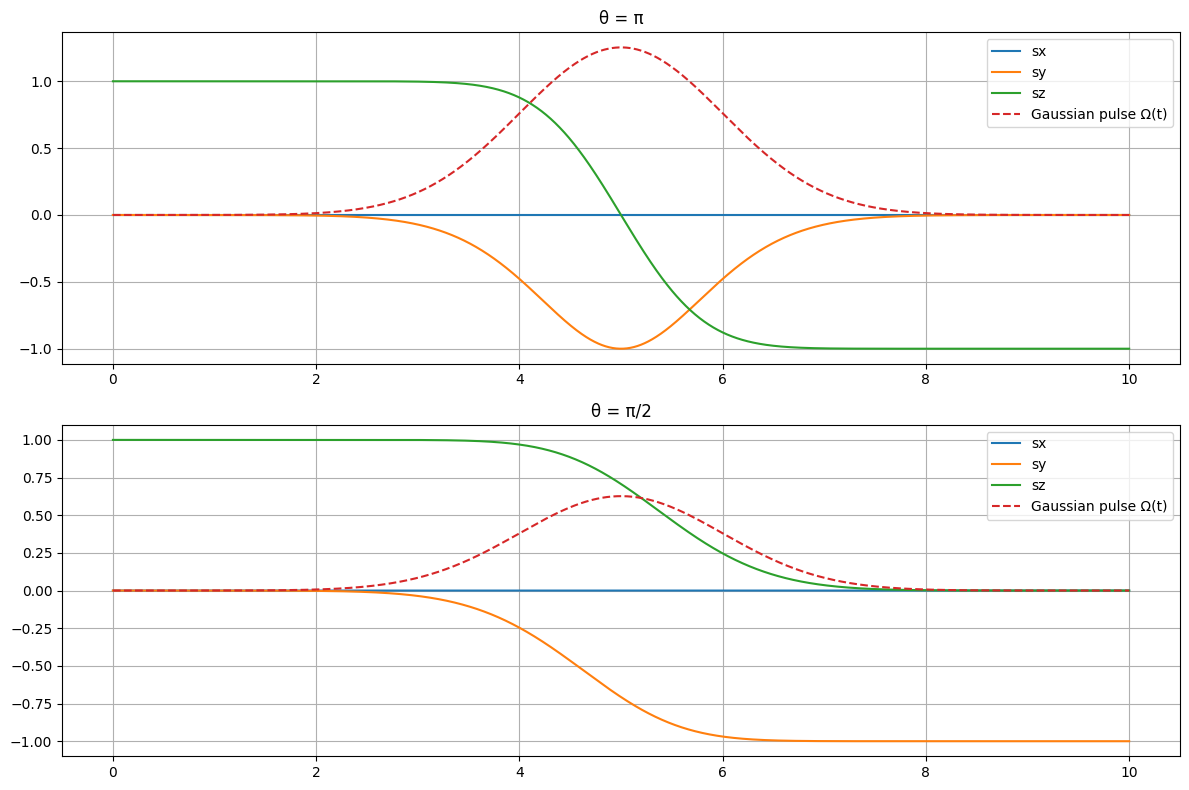

In [46]:


def gaussian(t, t0, sigma):
    return np.exp(-((t - t0)**2) / (2 * sigma**2)) / (sigma * np.sqrt(2*np.pi))

def Omega(t, theta, t0, sigma):
    return theta * gaussian(t, t0, sigma) # for ploting

def H(t, args):
    theta = args["theta"]
    t0 = args["t0"]
    sigma = args["sigma"]
    return 0.5 * Omega(t, theta, t0, sigma) * sigmax()

tlist = np.linspace(0, 10, 2000)
psi0 = basis(2, 0)

args1 = {"theta": np.pi, "t0": 5.0, "sigma": 1}
result1 = sesolve(H, psi0, tlist, args=args1)

sx1 = expect(sigmax(), result1.states)
sy1 = expect(sigmay(), result1.states)
sz1 = expect(sigmaz(), result1.states)

Omega1 = Omega(tlist, np.pi, 5.0, 1)

args2 = {"theta": np.pi/2, "t0": 5.0, "sigma": 1}
result2 = sesolve(H, psi0, tlist, args=args2)

sx2 = expect(sigmax(), result2.states)
sy2 = expect(sigmay(), result2.states)
sz2 = expect(sigmaz(), result2.states)

Omega2 = Omega(tlist, np.pi/2, 5.0, 1)

plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.title("θ = π")
plt.plot(tlist, sx1, label="sx")
plt.plot(tlist, sy1, label="sy")
plt.plot(tlist, sz1, label="sz")
plt.plot(tlist, Omega1, "--", label="Gaussian pulse Ω(t)")
plt.legend()
plt.grid()

plt.subplot(2,1,2)
plt.title("θ = π/2")
plt.plot(tlist, sx2, label="sx")
plt.plot(tlist, sy2, label="sy")
plt.plot(tlist, sz2, label="sz")
plt.plot(tlist, Omega2, "--", label="Gaussian pulse Ω(t)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


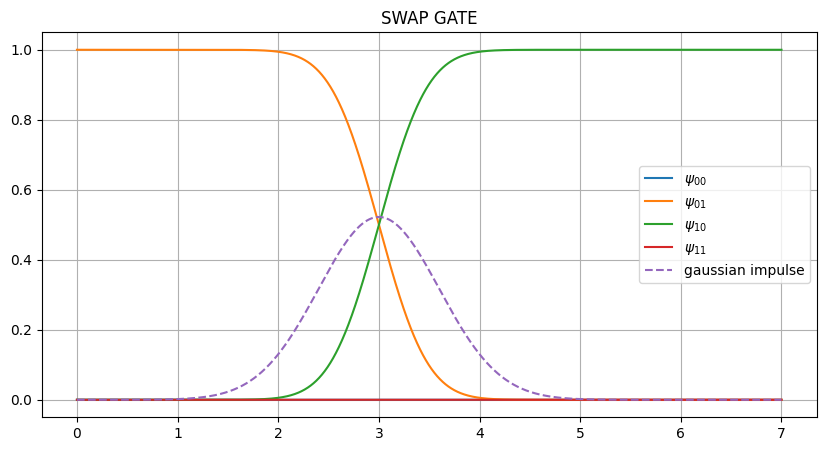

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, tensor, sesolve, expect

def gaussian(t, t0, sigma):
    return np.exp(-((t - t0)**2) / (2 * sigma**2)) / (sigma * np.sqrt(2*np.pi))

def J(t, J0, t0, sigma):
    return J0 * gaussian(t, t0, sigma)

def H(t, args):
    J0 = args["J0"]
    t0 = args["t0"]
    sigma = args["sigma"]

    Jt = J(t, J0, t0, sigma)

    sx1 = tensor(sigmax(), qeye(2))
    sy1 = tensor(sigmay(), qeye(2))
    sz1 = tensor(sigmaz(), qeye(2))

    sx2 = tensor(qeye(2), sigmax())
    sy2 = tensor(qeye(2), sigmay())
    sz2 = tensor(qeye(2), sigmaz())

    return Jt * (sx1*sx2 + sy1*sy2 + sz1*sz2)

tlist = np.linspace(0, 7, 2000)

psi00 = tensor(basis(2,0), basis(2,0))
psi01 = tensor(basis(2,0), basis(2,1))
psi10 = tensor(basis(2,1), basis(2,0))
psi11 = tensor(basis(2,1), basis(2,1))

args = {"J0": np.pi/4, "t0": 3.0, "sigma": 0.6}

result = sesolve(H, psi01, tlist, args=args)

P00 = [abs((st.overlap(psi00)))**2 for st in result.states]
P01 = [abs((st.overlap(psi01)))**2 for st in result.states]
P10 = [abs((st.overlap(psi10)))**2 for st in result.states]
P11 = [abs((st.overlap(psi11)))**2 for st in result.states]

Jt = J(tlist, np.pi/4, 3.0, 0.6)

plt.figure(figsize=(10,5))
plt.plot(tlist, P00, label=r"$\psi_{00}$")
plt.plot(tlist, P01, label=r"$\psi_{01}$")
plt.plot(tlist, P10, label=r"$\psi_{10}$")
plt.plot(tlist, P11, label=r"$\psi_{11}$")
plt.plot(tlist, Jt, "--", label="gaussian impulse")
plt.title("SWAP GATE")
plt.legend()
plt.grid()
plt.show()

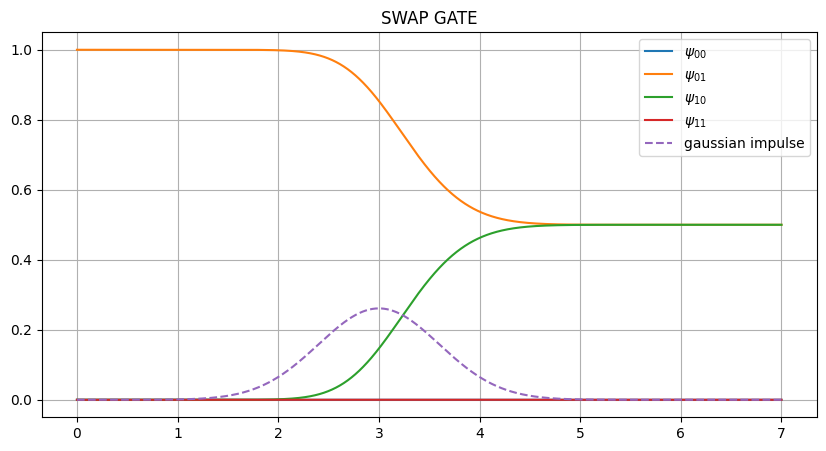

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, tensor, sesolve, expect

def gaussian(t, t0, sigma):
    return np.exp(-((t - t0)**2) / (2 * sigma**2)) / (sigma * np.sqrt(2*np.pi))

def J(t, J0, t0, sigma):
    return J0 * gaussian(t, t0, sigma)

def H(t, args):
    J0 = args["J0"]
    t0 = args["t0"]
    sigma = args["sigma"]

    Jt = J(t, J0, t0, sigma)

    sx1 = tensor(sigmax(), qeye(2))
    sy1 = tensor(sigmay(), qeye(2))
    sz1 = tensor(sigmaz(), qeye(2))

    sx2 = tensor(qeye(2), sigmax())
    sy2 = tensor(qeye(2), sigmay())
    sz2 = tensor(qeye(2), sigmaz())

    return Jt * (sx1*sx2 + sy1*sy2 + sz1*sz2)

tlist = np.linspace(0, 7, 2000)

psi00 = tensor(basis(2,0), basis(2,0))
psi01 = tensor(basis(2,0), basis(2,1))
psi10 = tensor(basis(2,1), basis(2,0))
psi11 = tensor(basis(2,1), basis(2,1))

args = {"J0": np.pi/8, "t0": 3.0, "sigma": 0.6}

result = sesolve(H, psi01, tlist, args=args)

P00 = [abs((st.overlap(psi00)))**2 for st in result.states]
P01 = [abs((st.overlap(psi01)))**2 for st in result.states]
P10 = [abs((st.overlap(psi10)))**2 for st in result.states]
P11 = [abs((st.overlap(psi11)))**2 for st in result.states]

Jt = J(tlist, np.pi/8, 3.0, 0.6)

plt.figure(figsize=(10,5))
plt.plot(tlist, P00, label=r"$\psi_{00}$")
plt.plot(tlist, P01, label=r"$\psi_{01}$")
plt.plot(tlist, P10, label=r"$\psi_{10}$")
plt.plot(tlist, P11, label=r"$\psi_{11}$")
plt.plot(tlist, Jt, "--", label="gaussian impulse")
plt.title("SWAP GATE")
plt.legend()
plt.grid()
plt.show()